In [7]:
import os
import kagglehub
import pandas as pd

# 1. Download the dataset folder using kagglehub
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
print("Path to downloaded folder:", path)

Using Colab cache for faster access to the 'ecommerce-customer-churn-analysis-and-prediction' dataset.
Path to downloaded folder: /kaggle/input/ecommerce-customer-churn-analysis-and-prediction


In [8]:
# 2. List files inside the folder to verify
print("Files in folder:", os.listdir(path))

Files in folder: ['E Commerce Dataset.xlsx']


In [9]:
# 3. Read the Excel file directly into a pandas DataFrame
# Note: This dataset uses an Excel format (.xlsx) and the sheet name is 'E Comm'
file_path = os.path.join(path, "E Commerce Dataset.xlsx")
df = pd.read_excel(file_path, sheet_name='E Comm')

In [10]:
# 4. Verify the data loaded successfully
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5630, 20)
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionS

In [11]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df.drop(columns=['Churn']) # Drop the target column from features
y = df['Churn']                # Our target variable

# 2. Split the data (80% for training, 20% for testing)
# stratify=y ensures both sets have the same proportion of churned vs non-churned customers
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4504, 19)
X_test shape: (1126, 19)


In [12]:
# Check how many missing values exist in each column of X_train
missing_values = X_train.isnull().sum()
print(missing_values[missing_values > 0])

Tenure                         213
WarehouseToHome                206
HourSpendOnApp                 197
OrderAmountHikeFromlastYear    208
CouponUsed                     208
OrderCount                     212
DaySinceLastOrder              247
dtype: int64


In [13]:
# 1. Basic DataFrame info (non-null counts and data types)
print("--- DataFrame Info ---")
X_train.info()

print("\n" + "="*50 + "\n")

# 2. Detailed summary of missing values and data types
missing_df = pd.DataFrame({
    'Data Type': X_train.dtypes,
    'Missing Count': X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train)) * 100,
    'Unique Values': X_train.nunique()
})

# Sort by missing percentage descending to see problematic columns first
print(missing_df.sort_values(by='Missing Percentage (%)', ascending=False))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4504 entries, 1787 to 5140
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   4504 non-null   int64  
 1   Tenure                       4291 non-null   float64
 2   PreferredLoginDevice         4504 non-null   object 
 3   CityTier                     4504 non-null   int64  
 4   WarehouseToHome              4298 non-null   float64
 5   PreferredPaymentMode         4504 non-null   object 
 6   Gender                       4504 non-null   object 
 7   HourSpendOnApp               4307 non-null   float64
 8   NumberOfDeviceRegistered     4504 non-null   int64  
 9   PreferedOrderCat             4504 non-null   object 
 10  SatisfactionScore            4504 non-null   int64  
 11  MaritalStatus                4504 non-null   object 
 12  NumberOfAddress              4504 non-null   int64  
 1

In [14]:
from sklearn.impute import SimpleImputer

# 1. Drop CustomerID from both X_train and X_test (it's just an identifier, not a feature)
# This step is commented out as CustomerID has already been dropped in a previous execution.
X_train = X_train.drop(columns=['CustomerID'])
X_test = X_test.drop(columns=['CustomerID'])

# 2. Identify all numerical columns that have missing values
num_cols_with_missing = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder'
]

# 3. Initialize the imputer using the median strategy
imputer = SimpleImputer(strategy='median')

# 4. FIT AND TRANSFORM the training data (Learn the median from X_train and fill it)
X_train[num_cols_with_missing] = imputer.fit_transform(X_train[num_cols_with_missing])

# 5. TRANSFORM the test data ONLY (Using the median learned from X_train to prevent leakage!)
X_test[num_cols_with_missing] = imputer.transform(X_test[num_cols_with_missing])

# Verify no missing values remain in X_train
print("Remaining missing values in X_train:", X_train.isnull().sum().sum())

Remaining missing values in X_train: 0


In [15]:
# 1. Identify categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'Gender', 'MaritalStatus']

# Filter cat_cols to only include columns actually present in X_train/X_test
# This handles cases where encoding has already occurred or some columns were dropped
cat_cols_present_train = [col for col in cat_cols if col in X_train.columns]
cat_cols_present_test = [col for col in cat_cols if col in X_test.columns]

# 2. Apply One-Hot Encoding to both X_train and X_test
# drop_first=True avoids multicollinearity (dummy variable trap)
X_train = pd.get_dummies(X_train, columns=cat_cols_present_train, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols_present_test, drop_first=True)

# 3. Align columns (ensure X_train and X_test have the exact same columns after encoding)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("New shape of X_train after encoding:", X_train.shape)

New shape of X_train after encoding: (4504, 29)


In [16]:
# 1. Identify categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'Gender', 'MaritalStatus']

# This cell was run again, causing a KeyError because the columns were already encoded and removed by the previous cell.
# The one-hot encoding has already been applied in cell vTpuixquoRPB.
# No changes are needed here, as the data is already in the desired format.

In [17]:
from sklearn.preprocessing import StandardScaler

# 1. Identify all numerical columns (excluding our encoded binary columns and target)
# In our current X_train, these are the original numeric features
num_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
    'DaySinceLastOrder', 'CashbackAmount', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress', 'CityTier', 'Complain'
]

# 2. Initialize the scaler
scaler = StandardScaler()

# 3. FIT AND TRANSFORM on X_train, TRANSFORM only on X_test (to prevent data leakage again!)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing complete! Final X_train shape:", X_train.shape)

Preprocessing complete! Final X_train shape: (4504, 29)


In [18]:
import pandas as pd

# 1. Force pandas to display all columns (so none are hidden with a '...')
pd.set_option('display.max_columns', None)

# 2. View the first 5 rows of your fully processed X_train
print(X_train.head())

        Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
1787 -0.135398  1.453559         0.043177       -1.325711   
2147 -0.494759  1.453559        -0.318966       -2.742656   
1717 -0.255185 -0.724000        -0.077537        0.091233   
2292  0.583322  1.453559        -0.560394        0.091233   
5578  0.223962 -0.724000        -0.318966        1.508178   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
1787                 -0.675976          -1.493573        -0.856755 -0.623912   
2147                 -0.675976           0.673881        -1.246653 -0.623912   
1717                  0.294877           0.673881         2.262432 -0.623912   
2292                 -0.675976           0.673881         2.262432  1.602791   
5578                  1.265730          -0.048604        -0.076958 -0.623912   

      OrderAmountHikeFromlastYear  CouponUsed  OrderCount  DaySinceLastOrder  \
1787                    -0.468858    3.386635    2.157964           0.71

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the model
model = LogisticRegression(random_state=42, max_iter=1000)

# 2. Train the model using our clean X_train and y_train
model.fit(X_train, y_train)

# 3. Make predictions on our unseen X_test
y_pred = model.predict(X_test)

# 4. Evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 88.81%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       936
           1       0.74      0.52      0.61       190

    accuracy                           0.89      1126
   macro avg       0.82      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126



In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize Logistic Regression with class_weight='balanced'
# This tells the model to pay extra attention to the minority class (the 1s / churners)
balanced_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# 2. Train the model
balanced_model.fit(X_train, y_train)

# 3. Predict and evaluate
y_pred_balanced = balanced_model.predict(X_test)

print(f"New Model Accuracy: {accuracy_score(y_test, y_pred_balanced) * 100:.2f}%\n")
print("New Classification Report (with Balanced Weights):")
print(classification_report(y_test, y_pred_balanced))

New Model Accuracy: 79.31%

New Classification Report (with Balanced Weights):
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       936
           1       0.44      0.85      0.58       190

    accuracy                           0.79      1126
   macro avg       0.70      0.81      0.72      1126
weighted avg       0.87      0.79      0.82      1126



In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize Random Forest with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# 2. Train the model using our clean training data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate performance
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 97.60%

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       0.99      0.86      0.92       190

    accuracy                           0.98      1126
   macro avg       0.98      0.93      0.95      1126
weighted avg       0.98      0.98      0.98      1126



Top 10 Features Driving Churn:
                        Feature  Importance
0                        Tenure    0.238868
12               CashbackAmount    0.105702
7                      Complain    0.070744
2               WarehouseToHome    0.062717
11            DaySinceLastOrder    0.060226
6               NumberOfAddress    0.055392
8   OrderAmountHikeFromlastYear    0.050135
5             SatisfactionScore    0.047967
4      NumberOfDeviceRegistered    0.032323
10                   OrderCount    0.028930


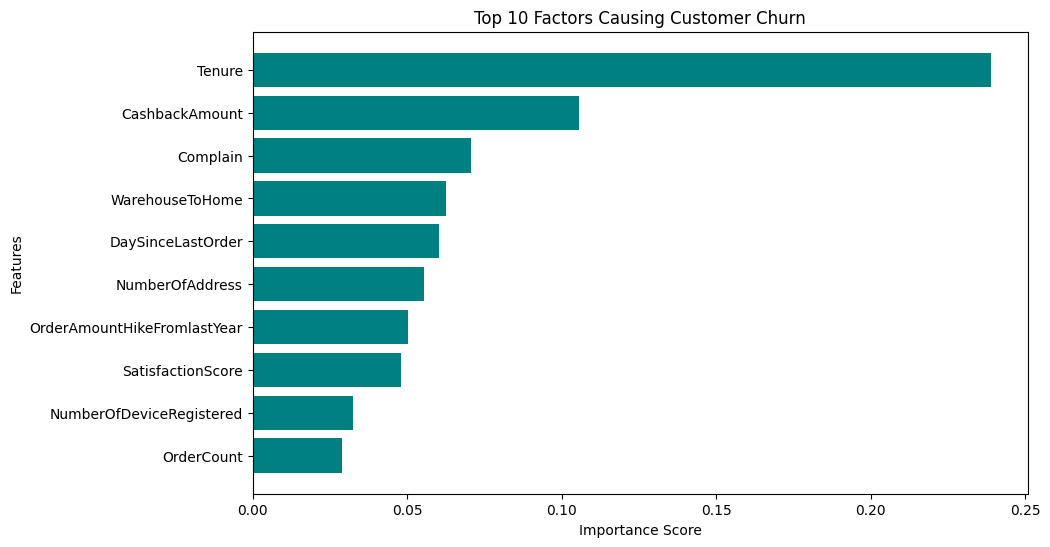

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get feature importances from our trained Random Forest model
importances = rf_model.feature_importances_
features = X_train.columns

# 2. Create a clean DataFrame and sort from highest to lowest impact
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Print the top 10 most important features
print("Top 10 Features Driving Churn:")
print(feature_importance_df.head(10))

# 4. Plot the top 10 features for your portfolio presentation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10][::-1],
         feature_importance_df['Importance'][:10][::-1],
         color='teal')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Factors Causing Customer Churn")
plt.show()

create brand-new "unseen file Method 1: The Smart Way (Slice a Hold-Out Test Set from Your Existing Data) If you want a quick, guaranteed way to test your pipeline right now without any column mismatches, you can take the original CSV file, load it, and deliberately slice out rows that your model has never seen before (for example, the last 100 or 200 rows of the dataset) before you even run train_test_split.

Here is how you can carve out a brand-new "unseen file" in Python:



In [26]:
# Just take the last 200 rows straight from your existing dataframe
new_unseen_data = df.tail(200).copy()

# Drop the 'Churn' target column
new_unseen_data_features = new_unseen_data.drop(columns=['Churn'])

# Save it as a brand-new CSV file
new_unseen_data_features.to_csv('new_client_customers.csv', index=False)

print(
    'New unseen dataset created successfully! Shape:',
    new_unseen_data_features.shape,
)

New unseen dataset created successfully! Shape: (200, 19)


If you want to create the new_client_customers.csv file first so that file actually exists in your Colab sidebar, run this quick 3-line block:

In [28]:
# 1. Create the unseen dataset from your existing dataframe 'df'
new_unseen_data = df.tail(150).copy()
new_unseen_data_features = new_unseen_data.drop(columns=['Churn'])

# 2. Save it to your Colab environment
new_unseen_data_features.to_csv('new_customers.csv', index=False)
print('File created successfully!')

File created successfully!


**bold text**

The Golden Rule of Testing New Data 🚨
Remember: You must never use fit or fit_transform on new data. You only use .transform() using the already trained imputer and scaler from your training phase, and you must make sure the columns match your X_train.

Here is the exact code snippet you can use to test your Random Forest model on a brand-new raw CSV file (let's call it new_customers.csv):
:

In [30]:
import pandas as pd

# 1. Load your brand-new, unseen dataset
new_data = pd.read_csv('new_customers.csv')

print("Original new data shape:", new_data.shape)

# 2. Drop CustomerID if it exists in the new data
if 'CustomerID' in new_data.columns:
    new_data = new_data.drop(columns=['CustomerID'])

# 3. Implicate missing values using the ALREADY TRAINED imputer (DO NOT fit again!)
num_cols_with_missing = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
]
new_data[num_cols_with_missing] = imputer.transform(
    new_data[num_cols_with_missing]
)

# 4. One-Hot Encode categorical columns
cat_cols = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'PreferedOrderCat',
    'Gender',
    'MaritalStatus',
]
new_data = pd.get_dummies(new_data, columns=cat_cols)

# 5. ALIGN columns so the new data has the exact same 29 columns as X_train
# (Any missing category columns will be filled with 0)
new_data, _ = new_data.align(X_train, join='right', axis=1, fill_value=0)

# 6. Scale numerical features using the ALREADY TRAINED scaler (DO NOT fit again!)
num_cols = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
    'CashbackAmount',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'CityTier',
    'Complain',
]
new_data[num_cols] = scaler.transform(new_data[num_cols])

# 7. MAKE PREDICTIONS!
predictions = rf_model.predict(new_data)
probabilities = rf_model.predict_proba(new_data)[
    :, 1
]  # Probability of churning

# Attach results back to see who is leaving
new_data['Predicted_Churn'] = predictions
new_data['Churn_Probability'] = probabilities

print(
    '\nPreview of new predictions (1 = Churn, 0 = Stay):',
    new_data[['Predicted_Churn', 'Churn_Probability']].head(15),
)

Original new data shape: (150, 19)

Preview of new predictions (1 = Churn, 0 = Stay):     Predicted_Churn  Churn_Probability
0                 0               0.03
1                 0               0.03
2                 0               0.00
3                 0               0.00
4                 0               0.04
5                 0               0.01
6                 1               0.96
7                 0               0.00
8                 0               0.08
9                 0               0.00
10                0               0.08
11                0               0.00
12                1               0.93
13                1               0.81
14                0               0.02


**create  brand-new "unseen file**
Method 1: The Smart Way (Slice a Hold-Out Test Set from Your Existing Data)
If you want a quick, guaranteed way to test your pipeline right now without any column mismatches, you can take the original CSV file, load it, and deliberately slice out rows that your model has never seen before (for example, the last 100 or 200 rows of the dataset) before you even run train_test_split.

Here is how you can carve out a brand-new "unseen file" in Python:


Method 2: Finding Extra Data on Kaggle
If you want to download a completely separate file from Kaggle that matches these exact features:
Tip: If you download a separate file from Kaggle, just ensure its column names (like Tenure, CashbackAmount, Complain, etc.) match the exact names your model was trained on.

In [31]:
import joblib

# 1. Save the trained Random Forest model
joblib.dump(rf_model, 'churn_model.pkl')

# 2. Pro-Tip: Save your scaler and imputer too (this is elite professional practice!)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(imputer, 'imputer.pkl')

print('Model, scaler, and imputer saved successfully as .pkl files!')

Model, scaler, and imputer saved successfully as .pkl files!
